In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ตั้งค่าสไตล์กราฟ
sns.set_theme(style="whitegrid")

# ชี้ Path ไปที่โฟลเดอร์โปรเจกต์ของคุณตรงๆ เพื่อความชัวร์
BASE_DIR = Path("D:/Project-Resume/Thai Retail Intelligence")
DB_PATH = BASE_DIR / "data" / "retail_db.sqlite"

print(f"Connecting to database at: {DB_PATH}")
conn = sqlite3.connect(DB_PATH)
print("Connected successfully! ✅")

Connecting to database at: D:\Project-Resume\Thai Retail Intelligence\data\retail_db.sqlite
Connected successfully! ✅


,channel,total_sales
0,Shopee,1.513372e+09
1,Lazada,1.208182e+09
2,Website,1.204183e+09
3,TikTok Shop,9.078273e+08
4,LINE,6.097415e+08
5,Facebook,6.080059e+08


C:\Users\ASUS\AppData\Local\Temp\ipykernel_22556\3537788710.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_channel, x='channel', y='total_sales', palette='viridis')


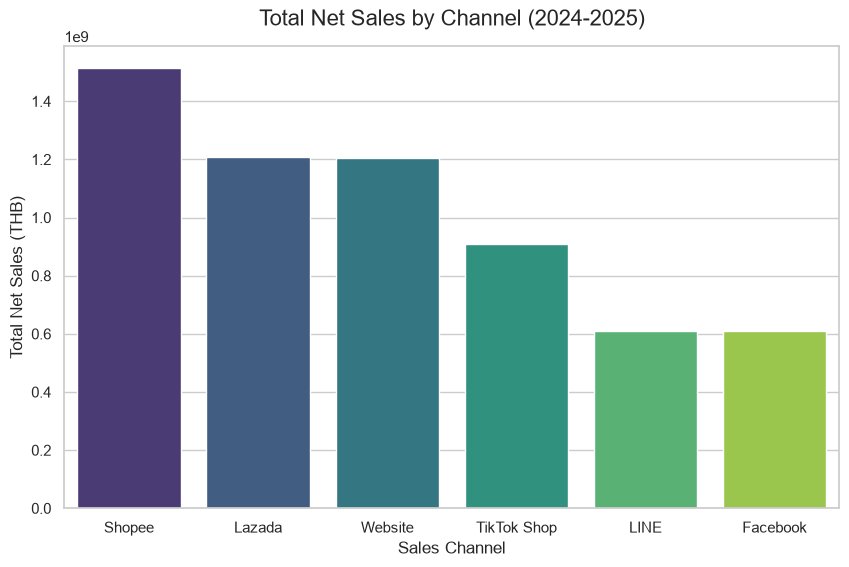

In [2]:
# ใช้ SQL เขียน Query ผ่าน Pandas
query_channel = """
SELECT channel, SUM(net_sales) as total_sales 
FROM fact_sales 
GROUP BY channel 
ORDER BY total_sales DESC
"""

# โหลดเข้า DataFrame
df_channel = pd.read_sql_query(query_channel, conn)

# แสดงตาราง 
display(df_channel)

# พล็อตกราฟ
plt.figure(figsize=(10, 6))
sns.barplot(data=df_channel, x='channel', y='total_sales', palette='viridis')
plt.title('Total Net Sales by Channel (2024-2025)', fontsize=16, pad=15)
plt.xlabel('Sales Channel', fontsize=12)
plt.ylabel('Total Net Sales (THB)', fontsize=12)
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_22556\2337367676.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_promo, y='promotion_name', x='total_profit', palette='magma')


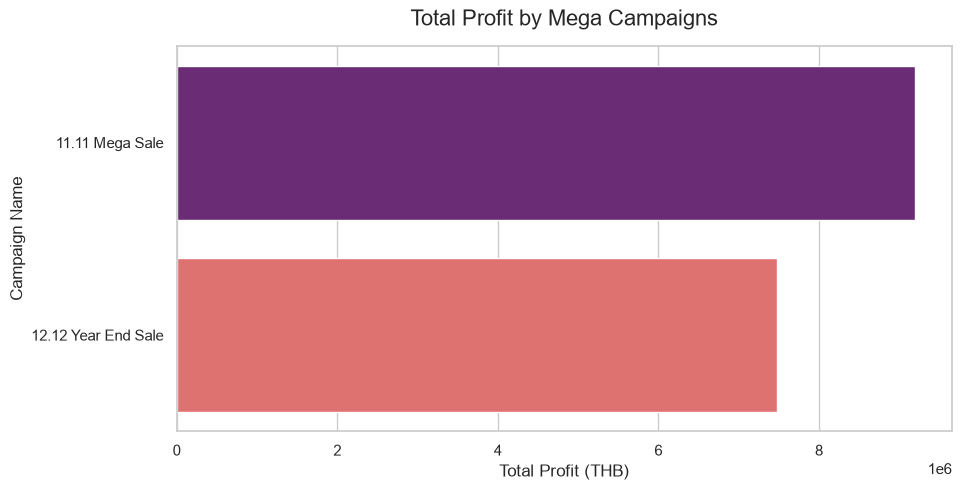

In [3]:
query_promo = """
SELECT 
    p.promotion_name, 
    SUM(f.profit) as total_profit
FROM fact_sales f
JOIN dim_promotions p ON f.promotion_id = p.promotion_id
WHERE p.event_type = 'Mega Campaign'
GROUP BY p.promotion_name
ORDER BY total_profit DESC
"""

df_promo = pd.read_sql_query(query_promo, conn)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_promo, y='promotion_name', x='total_profit', palette='magma')
plt.title('Total Profit by Mega Campaigns', fontsize=16, pad=15)
plt.xlabel('Total Profit (THB)', fontsize=12)
plt.ylabel('Campaign Name', fontsize=12)
plt.show()